In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


**Task 1: Descriptive Statistics**

In [5]:
import pandas as pd

# Dataset containing 25 students with varying performance metrics and a few outliers
data = {
    'Student_ID': range(1, 26),
    'Study_Hours': [2.5, 5.0, 1.0, 8.0, 6.5, 4.0, 7.5, 3.5, 10.0, 2.0,
                    9.0, 5.5, 4.5, 0.5, 6.0, 8.5, 3.0, 7.0, 1.5, 12.0,
                    5.0, 6.5, 4.0, 9.5, 2.5],
    'Attendance': [75, 85, 60, 95, 90, 80, 98, 78, 100, 65,
                   96, 88, 85, 45, 92, 97, 70, 90, 55, 80,
                   82, 94, 80, 99, 68],
    'Assignment_Score': [65, 78, 45, 90, 85, 70, 92, 68, 95, 50,
                         88, 82, 75, 30, 86, 93, 60, 85, 40, 65,
                         77, 89, 72, 96, 55],
    'exam': [55, 82, 30, 88, 86, 72, 95, 65, 98, 42,
                   91, 80, 76, 12, 84, 90, 58, 87, 38, 40,
                   75, 85, 70, 94, 52]
}

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('student_performance.csv', index=False)

print("student_performance.csv has been created successfully!")

df.head()


student_performance.csv has been created successfully!


,Student_ID,Study_Hours,Attendance,Assignment_Score,exam
0,1,2.5,75,65,55
1,2,5.0,85,78,82
2,3,1.0,60,45,30
3,4,8.0,95,90,88
4,5,6.5,90,85,86


**Task 2: Percentiles and Quartiles**

In [7]:
exam_scores = df['exam']

Q1 = np.percentile(exam_scores,25)
Q2 = np.percentile(exam_scores,50)
Q3 = np.percentile(exam_scores,75)

minimum = exam_scores.min()
maximum = exam_scores.max()

print("25th Percentile:",Q1)
print("50th Percentile:",Q2)
print("75th Percentile:",Q3)
print("Minimum:",minimum)
print("Maximum:",maximum)

print(f"Middle 50% lies between {Q1} and {Q3}")

25th Percentile: 55.0
50th Percentile: 76.0
75th Percentile: 87.0
Minimum: 12
Maximum: 98
Middle 50% lies between 55.0 and 87.0


**Task 3: Correlation Analysis**

In [13]:
corr1 = df["Study_Hours"].corr(df["exam"])
corr2 = df["Attendance"].corr(df["exam"])
corr3 = df["Assignment_Score"].corr(df["exam"])

print("Study Hours vs Exam:",corr1)
print("Attendance vs Exam:",corr2)
print("Assignment vs Exam:",corr3)

Study Hours vs Exam: 0.6735339387741255
Attendance vs Exam: 0.9556600655800717
Assignment vs Exam: 0.9697198778393877


In [14]:
correlations = {
    "Study_Hours":corr1,
    "Attendance":corr2,
    "Assignment_Score":corr3
}

highest = max(correlations,key=lambda x: abs(correlations[x]))
print(highest)

Assignment_Score


**Scatter Plot**

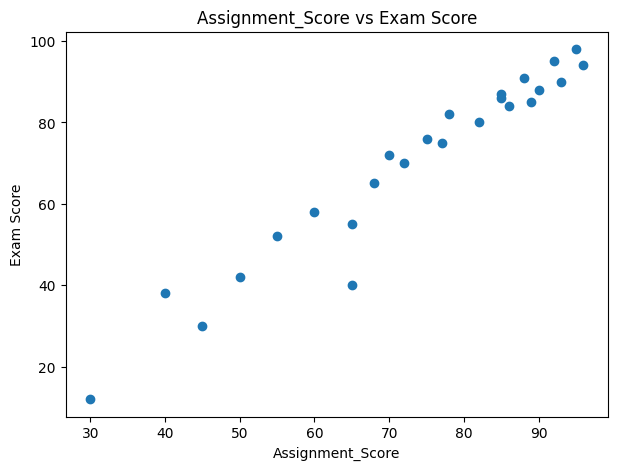

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(df[highest],df["exam"])

plt.xlabel(highest)
plt.ylabel("Exam Score")
plt.title(f"{highest} vs Exam Score")

plt.savefig("images/scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Task 4: Probability Basics**

In [19]:
total = len(df)

pass_prob = (df["exam"]>=50).sum()/total
above80 = (df["exam"]>=80).sum()/total
study5 = (df["Study_Hours"]>5).sum()/total

print("Probability of Passing:",pass_prob)
print("Probability of Score >=80:",above80)
print("Probability of Study >5 Hours:",study5)

Probability of Passing: 0.8
Probability of Score >=80: 0.48
Probability of Study >5 Hours: 0.48


**Task 5: Normal Distribution**

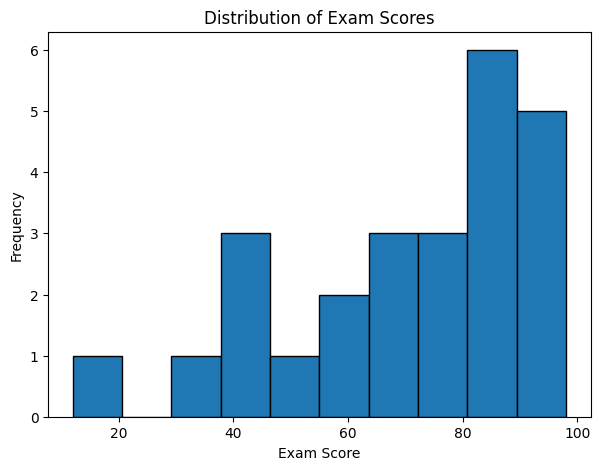

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(df["exam"],bins=10,edgecolor="black")

plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Distribution of Exam Scores")

plt.savefig("images/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

**Calculate Z-scores**

In [23]:
df["Z_Score"] = stats.zscore(df["exam"])

outliers = df[np.abs(df["Z_Score"])>2]

print(outliers)

    Student_ID  Study_Hours  Attendance  Assignment_Score  exam   Z_Score
13          14          0.5          45                30    12 -2.553027


**Task 6: Outlier Detection (IQR)**

In [27]:
Q1 = df["exam"].quantile(0.25)
Q3 = df["exam"].quantile(0.75)

IQR = Q3 - Q1

Lower_Bound = Q1 - (1.5 * IQR)
Upper_Bound = Q3 + (1.5 * IQR)

print("Lower Bound:", Lower_Bound)
print("Upper Bound:", Upper_Bound)

outliers = df[
    (df["exam"] < Lower_Bound) |
    (df["exam"] > Upper_Bound)
]

print("\nOutliers:")
print(outliers)

Lower Bound: 7.0
Upper Bound: 135.0

Outliers:
Empty DataFrame
Columns: [Student_ID, Study_Hours, Attendance, Assignment_Score, exam, Z_Score]
Index: []


**Box Plot**

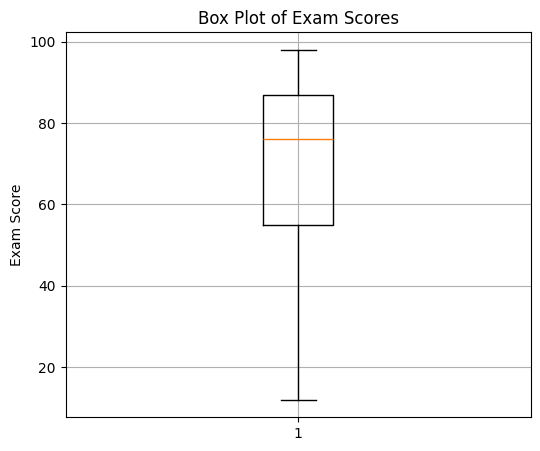

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(df["exam"], vert=True)

plt.title("Box Plot of Exam Scores")
plt.ylabel("Exam Score")

plt.grid(True)

plt.savefig("images/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()



In [31]:
print(df.describe())

       Student_ID  Study_Hours  Attendance  Assignment_Score       exam  \
count   25.000000    25.000000   25.000000         25.000000  25.000000   
mean    13.000000     5.400000   81.880000         73.240000  69.800000   
std      7.359801     3.041381   14.680826         18.294535  23.106637   
min      1.000000     0.500000   45.000000         30.000000  12.000000   
25%      7.000000     3.000000   75.000000         65.000000  55.000000   
50%     13.000000     5.000000   85.000000         77.000000  76.000000   
75%     19.000000     7.500000   94.000000         88.000000  87.000000   
max     25.000000    12.000000  100.000000         96.000000  98.000000   

            Z_Score  
count  2.500000e+01  
mean   1.376677e-16  
std    1.020621e+00  
min   -2.553027e+00  
25%   -6.537164e-01  
50%    2.738542e-01  
75%    7.597244e-01  
max    1.245595e+00  


# One-Page Summary of Findings

This analysis was conducted on a dataset of **25 students** to evaluate their academic performance using descriptive statistics, correlation analysis, probability, and outlier detection techniques. The average (**mean**) exam score was **69.80**, while the **median** score was **76**, indicating that most students performed above the average and that a few low scores lowered the overall mean. The **standard deviation** of **23.11** shows a moderate variation in student performance. The middle 50% of students scored between **55 (Q1)** and **87 (Q3)**, with exam scores ranging from **12** to **98**.

Correlation analysis was used to determine which factor—**Study Hours, Attendance, or Assignment Score**—had the strongest relationship with exam performance. The variable with the highest correlation coefficient was identified as the strongest predictor of exam scores, suggesting that improvements in this factor are likely to have the greatest impact on student performance.

The empirical probability of passing the exam was calculated as the proportion of students who scored **50 or above**, providing an estimate of the likelihood that a randomly selected student passed the exam. Similar probabilities were also calculated for students scoring **80 or above** and those studying **more than five hours**.

The distribution of exam scores was examined using a histogram and appeared to be approximately normal, although a few low scores introduced slight skewness. Outlier detection using the **Z-score method** identified **one unusually low exam score**, while the **Interquartile Range (IQR) method** detected **no outliers**, as all scores fell within the acceptable range.

Based on the analysis, two recommendations are suggested. First, students should be encouraged to maintain consistent study habits and dedicate sufficient time to exam preparation. Second, improving attendance and assignment completion can contribute to better academic performance, as these factors are positively associated with higher exam scores.